***
# <span style="font-family: 'Ubuntu'; font-weight: 200; font-size: 36px; color: indianred;">[1] Introdução</span>

***

### [1.1] Bibliotecas

In [708]:
from plots import print_caminho, caminho_para_grafo, plot_metricas

### [1.2] Dados do Problema

In [709]:
from modelagem import Estado
from modelagem import TEMPOS, PESSOAS

print(f"Dicionário de tempos: {TEMPOS}, Conjunto de pessoas: {PESSOAS}")

estado_inicial = Estado(grupo_inicio=PESSOAS, tocha_inicio=True)
estado_final = Estado(grupo_inicio=set(), tocha_inicio=False)
print(f"Estado inicial: {estado_inicial}")
print(f"Estado final: {estado_final}")

Dicionário de tempos: {'A': 1, 'B': 2, 'C': 5, 'D': 10}, Conjunto de pessoas: {'C', 'A', 'D', 'B'}
Estado inicial: {A, B, C, D} inicio
Estado final: {} final


***
# <span style="font-family: 'Ubuntu'; font-weight: 200; font-size: 36px; color: gray;">[2] Conhecendo a Modelagem</span>

***

### [2.1] Geração do Grupo Viajante

In [710]:
from modelagem import gerar_grupos_viajantes

print("possíveis grupos viajantes para o estado inicial: ")
for grupo_viajante in gerar_grupos_viajantes(PESSOAS):
    print(grupo_viajante, end=' ')

possíveis grupos viajantes para o estado inicial: 
{'C'} {'A'} {'D'} {'B'} {'C', 'A'} {'C', 'D'} {'C', 'B'} {'D', 'A'} {'A', 'B'} {'D', 'B'} 

### [2.2] Função Sucessora

In [711]:
from modelagem import funcao_sucessora

print("Sucessores do estado inicial:")
for passo in funcao_sucessora(estado_inicial):
    print(passo)

Sucessores do estado inicial:
Estado destino: {A, B, D} final; Passageiros: {C}; Custo: 5
Estado destino: {B, C, D} final; Passageiros: {A}; Custo: 1
Estado destino: {A, B, C} final; Passageiros: {D}; Custo: 10
Estado destino: {A, C, D} final; Passageiros: {B}; Custo: 2
Estado destino: {B, D} final; Passageiros: {A, C}; Custo: 5
Estado destino: {A, B} final; Passageiros: {C, D}; Custo: 10
Estado destino: {A, D} final; Passageiros: {B, C}; Custo: 5
Estado destino: {B, C} final; Passageiros: {A, D}; Custo: 10
Estado destino: {C, D} final; Passageiros: {A, B}; Custo: 2
Estado destino: {A, C} final; Passageiros: {B, D}; Custo: 10


***
# <span style="font-family: 'Ubuntu'; font-weight: 200; font-size: 36px; color: royalblue;">[3] Execução dos Algoritmos</span>

***

In [ ]:
resultados_algoritmos = {}
runs= 100 #execuções para média de tempo

### [3.1] Métodos de busca não informada

#### Busca em largura (BFS)

0: Estado inicial: {A, B, C, D} inicio
1: Passo: {'C', 'A'} levam a tocha para o final (custo: 5)
2: Passo: {'C'} levam a tocha para o inicio (custo: 5)
3: Passo: {'C', 'D'} levam a tocha para o final (custo: 10)
4: Passo: {'C'} levam a tocha para o inicio (custo: 5)
5: Passo: {'C', 'B'} levam a tocha para o final (custo: 5)
Estado final: {} final
Custo total: 30, Tempo: 0.000117s, Nós expandidos: 20


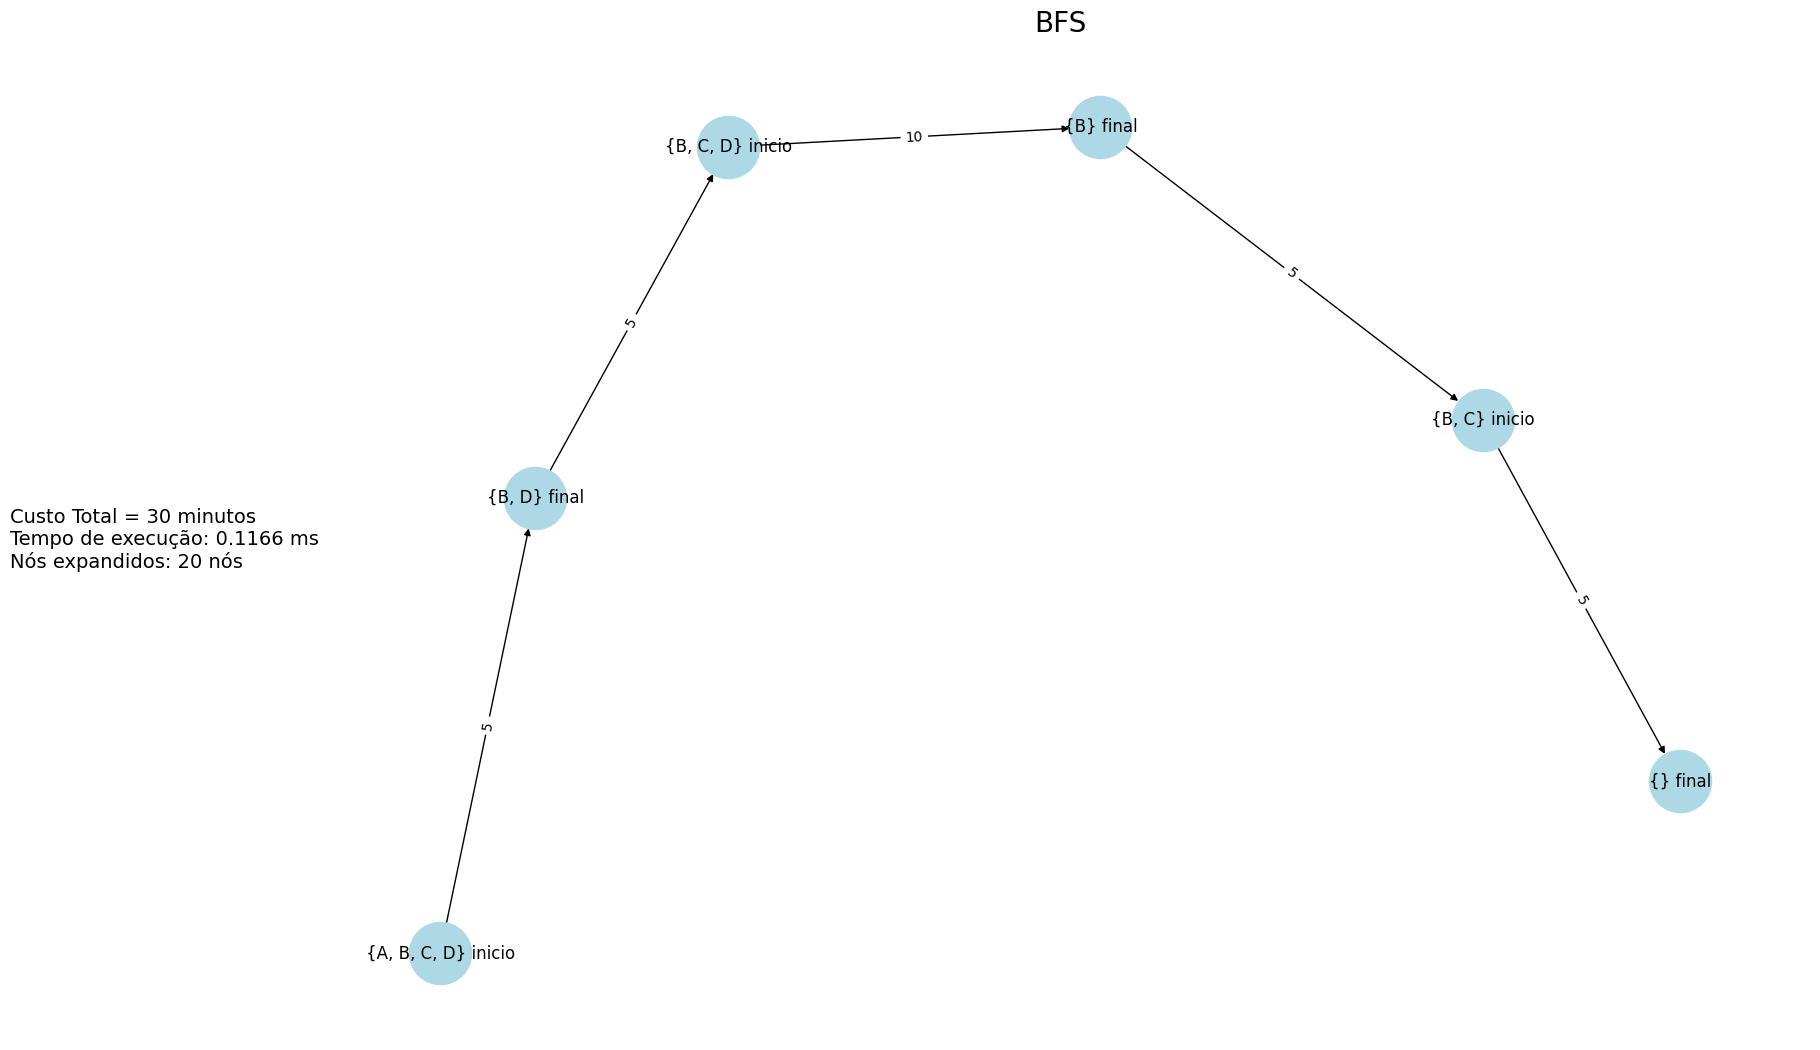

In [714]:
from algoritmos import bfs

time_BFS =  sum([bfs(estado_inicial, estado_final)[2] for _ in range(runs)])/runs
result_BFS = bfs(estado_inicial, estado_final)
resultados_algoritmos["BFS"] = (result_BFS[0], result_BFS[1], time_BFS, result_BFS[3])
caminho, custo_total, tempo, nos_expandidos = resultados_algoritmos["BFS"]
descricao = f"Custo Total = {custo_total} minutos\nTempo de execução: {round((tempo*1000),4)} ms\nNós expandidos: {nos_expandidos} nós"
print_caminho(caminho, estado_inicial, custo_total, tempo, nos_expandidos)
caminho_para_grafo(estado_inicial, caminho, "BFS", descricao)

#### Busca em profundidade (DFS)

0: Estado inicial: {A, B, C, D} inicio
1: Passo: {'D', 'B'} levam a tocha para o final (custo: 10)
2: Passo: {'B'} levam a tocha para o inicio (custo: 2)
3: Passo: {'A', 'B'} levam a tocha para o final (custo: 2)
4: Passo: {'D', 'B'} levam a tocha para o inicio (custo: 10)
5: Passo: {'C', 'B'} levam a tocha para o final (custo: 5)
6: Passo: {'A', 'B'} levam a tocha para o inicio (custo: 2)
7: Passo: {'D', 'B'} levam a tocha para o final (custo: 10)
8: Passo: {'B'} levam a tocha para o inicio (custo: 2)
9: Passo: {'A', 'B'} levam a tocha para o final (custo: 2)
Estado final: {} final
Custo total: 45, Tempo: 0.000072s, Nós expandidos: 13


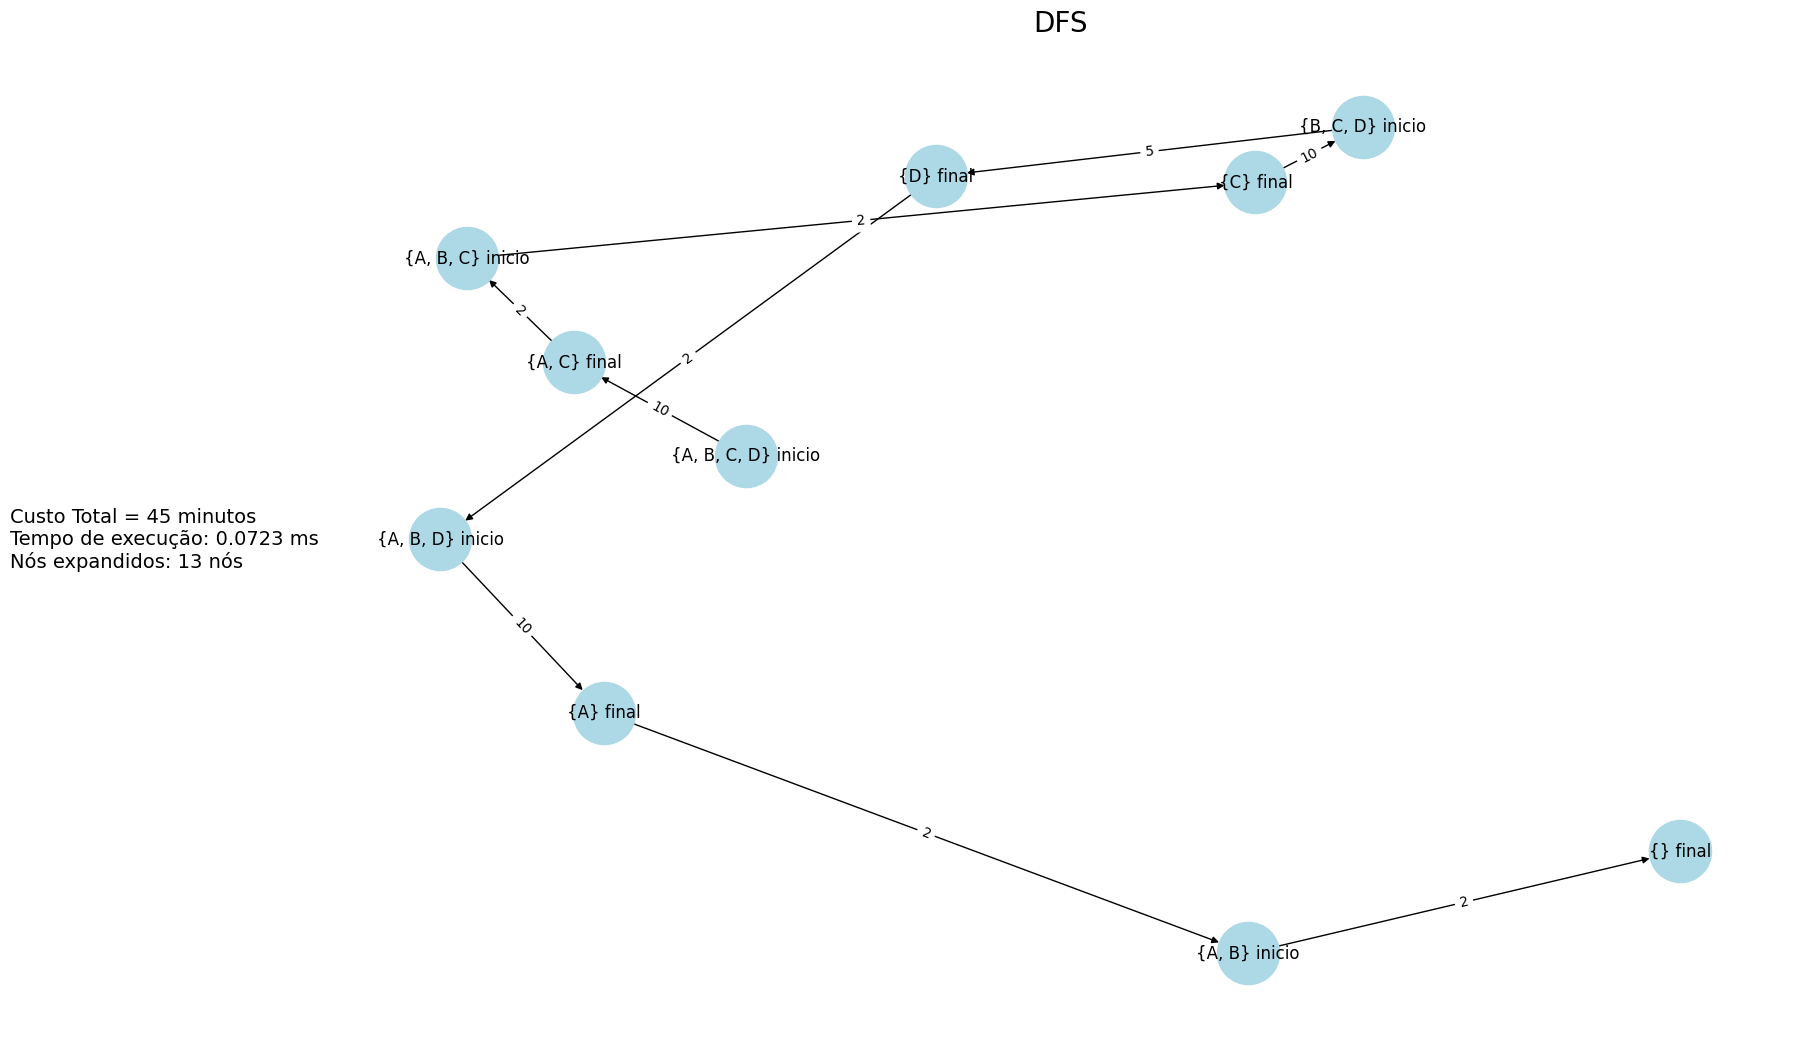

In [715]:
from algoritmos import dfs

time_DFS =  sum([dfs(estado_inicial, estado_final)[2] for _ in range(runs)])/runs
result_DFS = dfs(estado_inicial, estado_final)
resultados_algoritmos["DFS"] = (result_DFS[0], result_DFS[1], time_DFS, result_DFS[3])

caminho, custo_total, tempo, nos_expandidos = resultados_algoritmos["DFS"]
descricao = f"Custo Total = {custo_total} minutos\nTempo de execução: {round((tempo*1000),4)} ms\nNós expandidos: {nos_expandidos} nós"
print_caminho(caminho, estado_inicial, custo_total, tempo, nos_expandidos)
caminho_para_grafo(estado_inicial, caminho, "DFS", descricao)

### [3.2] Métodos de busca informada

#### Custo Uniforme

0: Estado inicial: {A, B, C, D} inicio
1: Passo: {'A', 'B'} levam a tocha para o final (custo: 2)
2: Passo: {'A'} levam a tocha para o inicio (custo: 1)
3: Passo: {'C', 'D'} levam a tocha para o final (custo: 10)
4: Passo: {'B'} levam a tocha para o inicio (custo: 2)
5: Passo: {'A', 'B'} levam a tocha para o final (custo: 2)
Estado final: {} final
Custo total: 17, Tempo: 0.000143s, Nós expandidos: 27


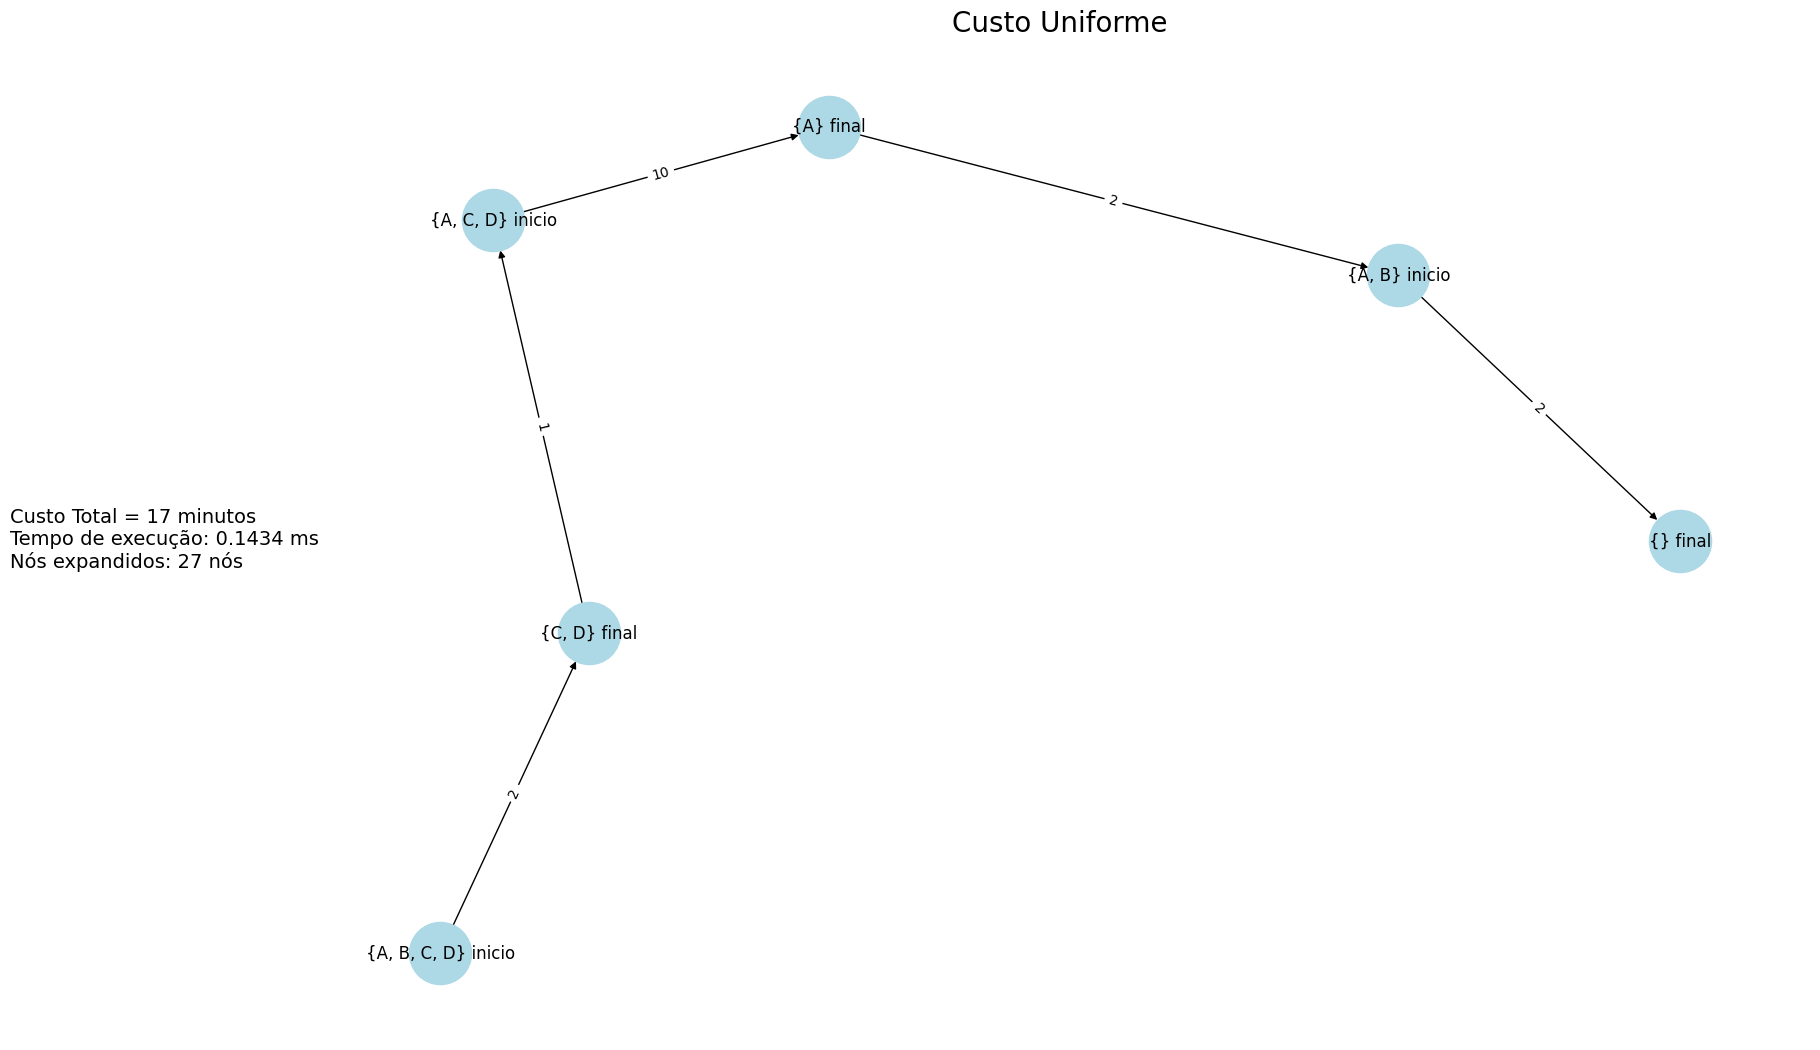

In [716]:
from algoritmos import custo_uniforme

time_Custo_Uniforme =  sum([custo_uniforme(estado_inicial, estado_final)[2] for _ in range(runs)])/runs
result_Custo_Uniforme = custo_uniforme(estado_inicial, estado_final)

resultados_algoritmos["Custo Uniforme"] = (result_Custo_Uniforme[0], result_Custo_Uniforme[1], time_Custo_Uniforme, result_Custo_Uniforme[3])
caminho, custo_total, tempo, nos_expandidos = resultados_algoritmos["Custo Uniforme"]
descricao = f"Custo Total = {custo_total} minutos\nTempo de execução: {round((tempo*1000),4)} ms\nNós expandidos: {nos_expandidos} nós"
print_caminho(caminho, estado_inicial, custo_total, tempo, nos_expandidos)
caminho_para_grafo(estado_inicial,caminho,"Custo Uniforme",descricao)

#### A-estrela

0: Estado inicial: {A, B, C, D} inicio
1: Passo: {'A', 'B'} levam a tocha para o final (custo: 2)
2: Passo: {'A'} levam a tocha para o inicio (custo: 1)
3: Passo: {'C', 'D'} levam a tocha para o final (custo: 10)
4: Passo: {'B'} levam a tocha para o inicio (custo: 2)
5: Passo: {'A', 'B'} levam a tocha para o final (custo: 2)
Estado final: {} final
Custo total: 17, Tempo: 0.000146s, Nós expandidos: 19


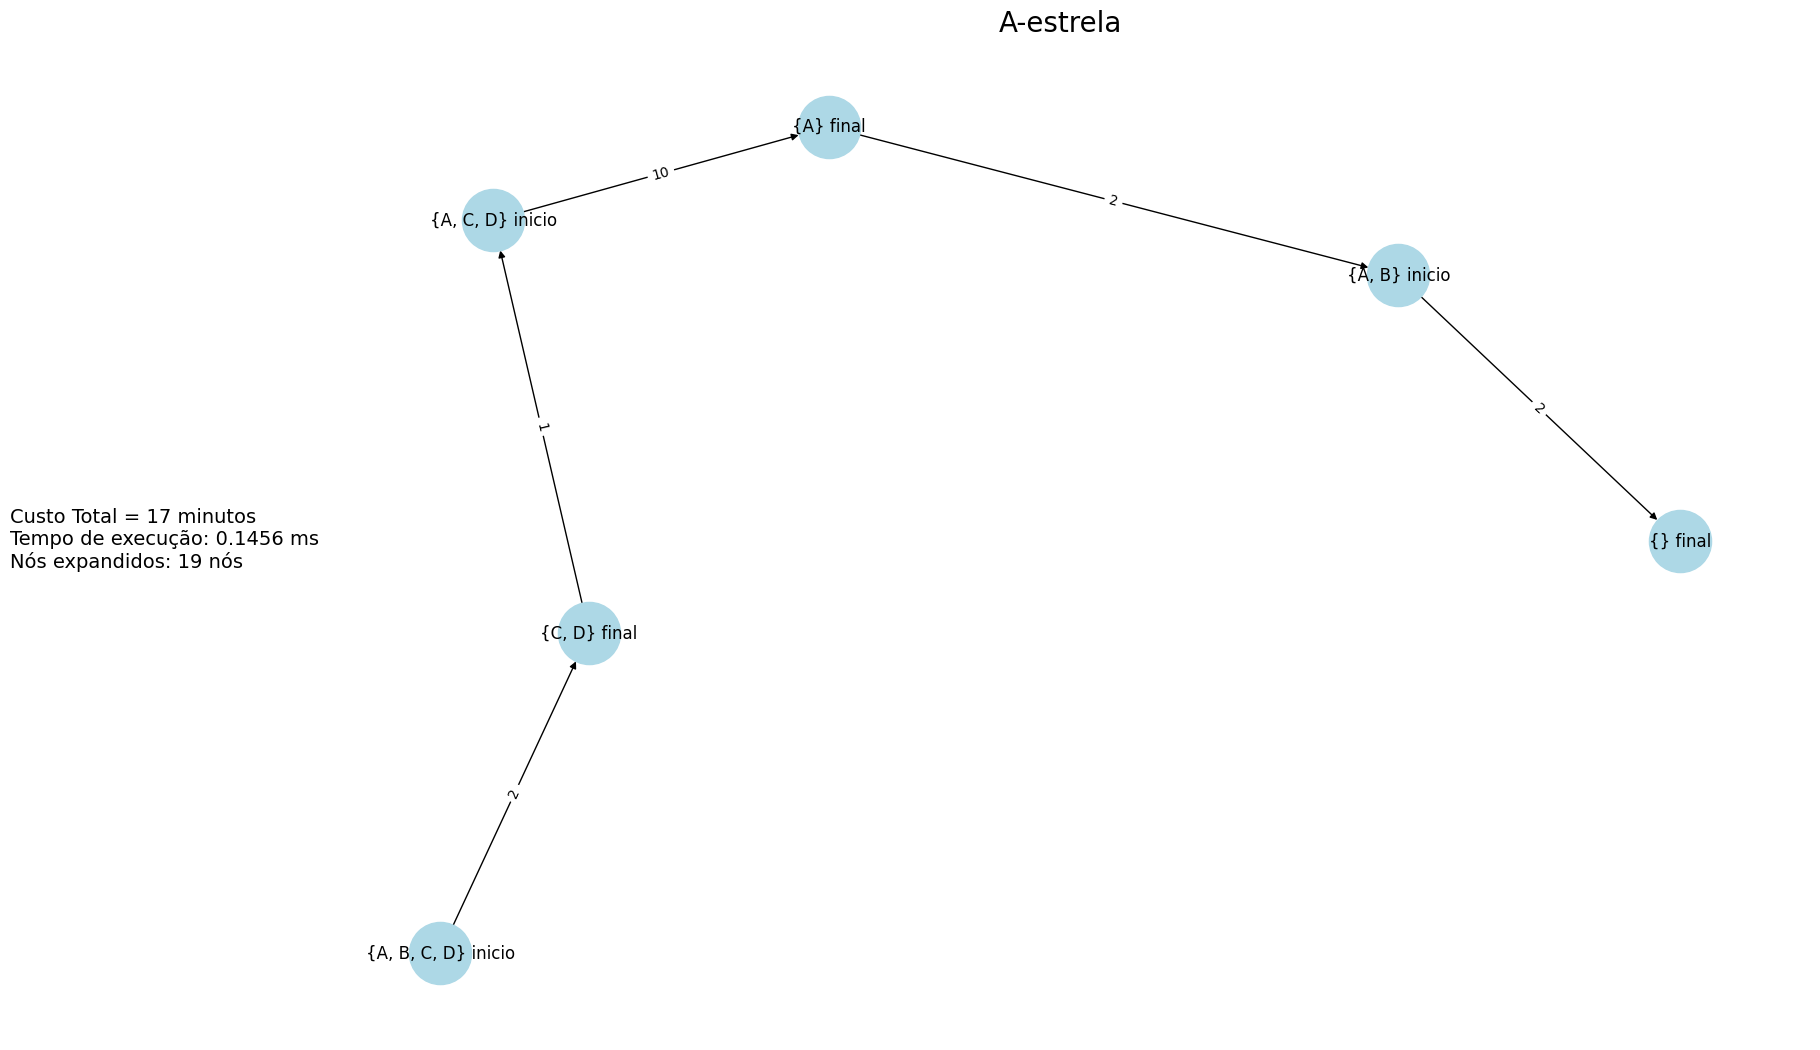

In [717]:
from algoritmos import a_estrela
from heuristicas import *


time_A_estrela =  sum([a_estrela(estado_inicial, estado_final, heuristica_maior_tempo_restante)[2] for _ in range(runs)])/runs
result_A_estrela = a_estrela(estado_inicial, estado_final, heuristica_maior_tempo_restante)

resultados_algoritmos["A-estrela"] = (result_A_estrela[0], result_A_estrela[1], time_A_estrela, result_A_estrela[3])
caminho, custo_total, tempo, nos_expandidos = resultados_algoritmos["A-estrela"]
descricao = f"Custo Total = {custo_total} minutos\nTempo de execução: {round((tempo*1000),4)} ms\nNós expandidos: {nos_expandidos} nós"
print_caminho(caminho, estado_inicial, custo_total, tempo, nos_expandidos)
caminho_para_grafo(estado_inicial, caminho, "A-estrela", descricao)

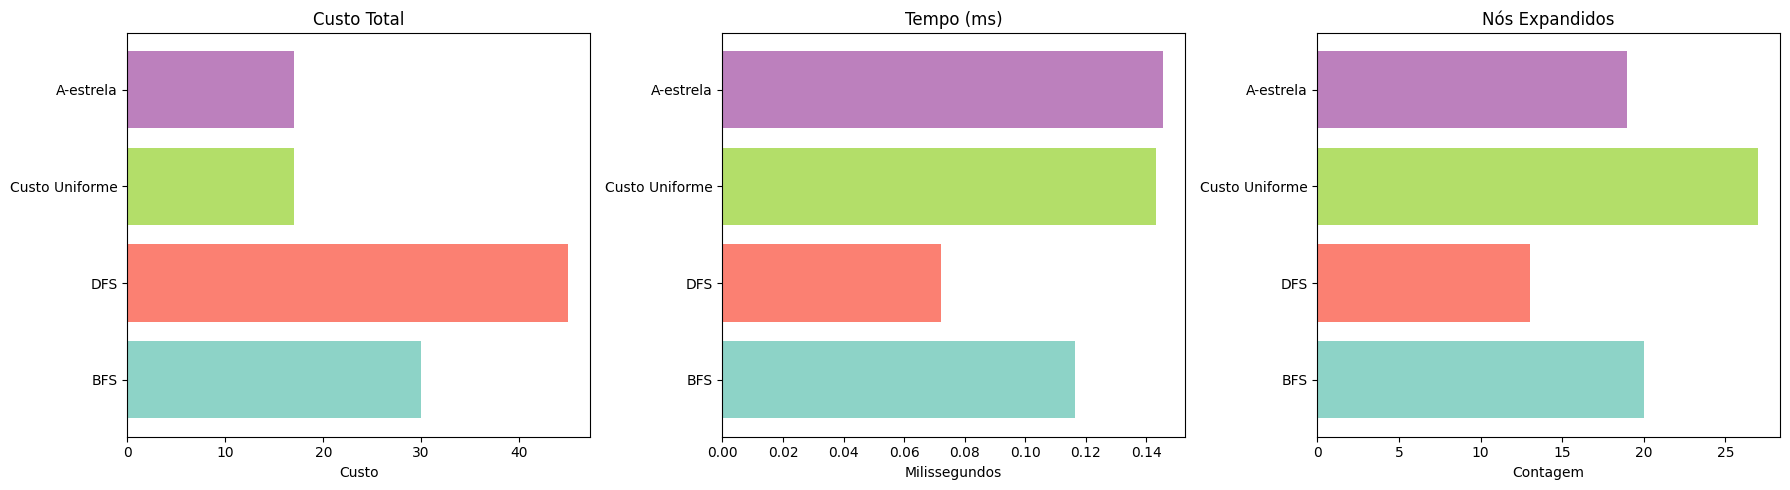

In [718]:
plot_metricas(resultados_algoritmos,"Set3")

***
# <span style="font-family: 'Ubuntu'; font-weight: 200; font-size: 36px; color: orange;">[4] Outras visualizações</span>

***

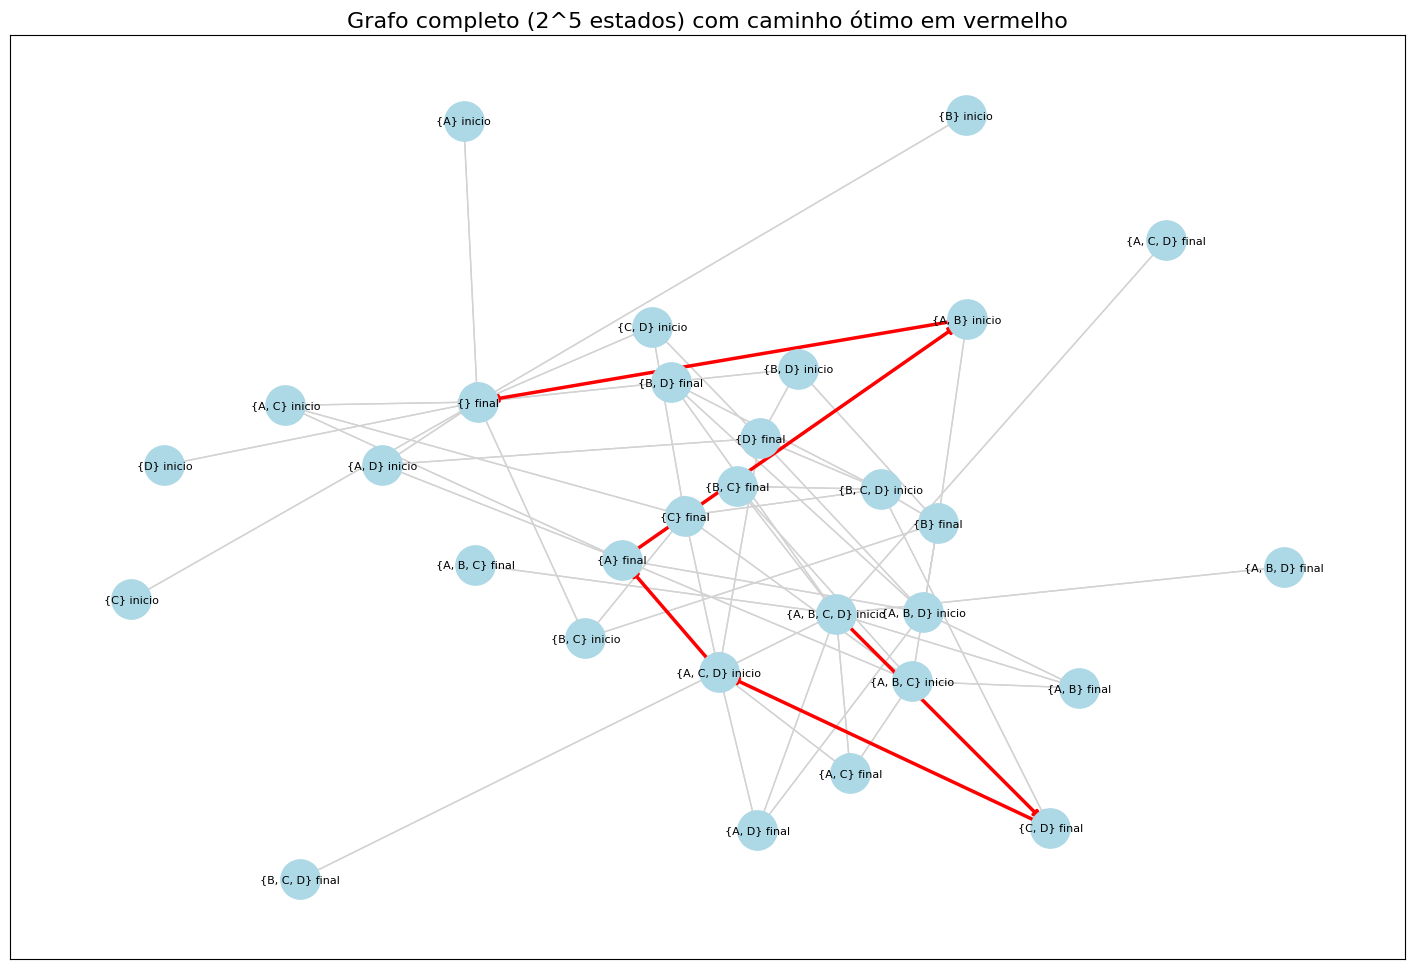

In [719]:
from plots import construir_grafo_completo, plotar_grafo_completo_com_caminho

G_completo = construir_grafo_completo()
caminho_otimo = resultados_algoritmos["Custo Uniforme"][0]  # ou "A-estrela"
plotar_grafo_completo_com_caminho(G_completo, caminho_otimo)